In [1]:
import numpy as np

In [2]:
np.random.seed(42)
n_samples=1200

In [3]:
raw_data = np.random.exponential(scale=2.0, size=n_samples)
raw_data[0:5] = 0.0     # force a few zeros
raw_data[5:10] = -0.5   # force a few negatives

In [4]:
from scipy import stats

In [5]:
print('\n***************Statisitical profile of raw data********************')


***************Statisitical profile of raw data********************


In [10]:
print(f'Mean-> {np.mean(raw_data):.2f} & Median-> {np.median(raw_data):.2f}')

Mean-> 1.99 & Median-> 1.40


In [19]:
print(f'Skewness-> {stats.skew(raw_data):.2f} Ideal=0')

Skewness-> 1.81 Ideal=0


In [20]:
print(f'Kurtosis-> {stats.kurtosis(raw_data):.2f} Ideal=0')

Kurtosis-> 4.69 Ideal=0


In [25]:
raw_data

array([0.        , 0.        , 0.        , ..., 6.93967133, 2.76980531,
       0.2787224 ], shape=(1200,))

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='Count'>

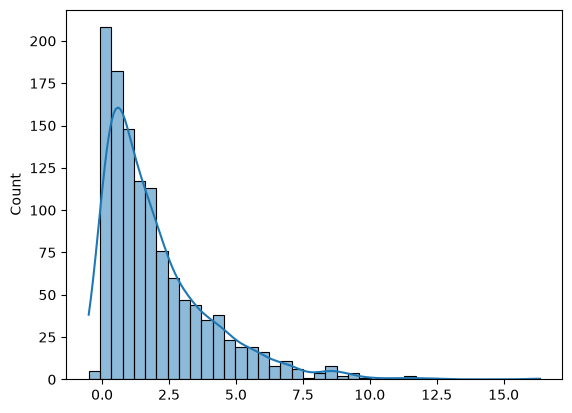

In [33]:
sns.histplot(raw_data, kde=True, bins='fd')

In [34]:
print(f'Minimum from data-> {abs(np.min(raw_data))}')

Minimum from data-> 0.5


In [35]:
print('\n---adding 1 to meet the condition of log transformer---')


---adding 1 to meet the condition of log transformer---


In [37]:
add1 = abs(np.min(raw_data)+1)

In [38]:
print('\n***Log Transformer***')


***Log Transformer***


In [40]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, QuantileTransformer 

In [41]:
log_trans= FunctionTransformer(func=np.log)

In [43]:
log_data=log_trans.transform(raw_data+add1).reshape(-1,1).flatten()

/home/best_buy/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_function_transformer.py:381: RuntimeWarning: divide by zero encountered in log
  return func(X, **(kw_args if kw_args else {}))


<Axes: ylabel='Count'>

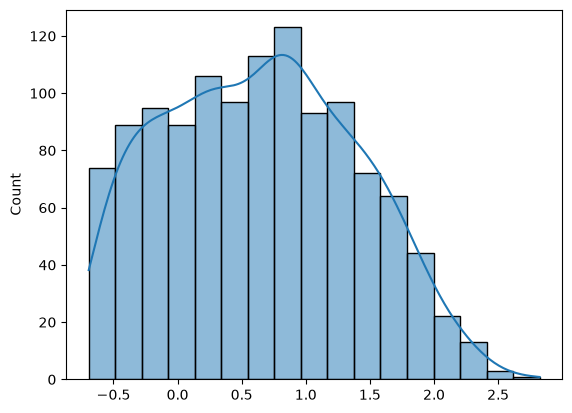

In [44]:
sns.histplot(log_data, kde=True, bins='fd')

In [48]:
print(np.mean(log_data))

-inf


In [53]:
print(f'{np.median(log_data):.2f}')

0.64


In [54]:
print(f'skewness-> {stats.skew(log_data):.2f}')

skewness-> nan


In [55]:
print(f'Kurtosis-> {stats.kurtosis(log_data):.2f}')

Kurtosis-> nan


In [56]:
#Read the warning above of 0 encountered

In [57]:
print('\n***Box-Cox Transformer***')


***Box-Cox Transformer***


In [59]:
box_cox=PowerTransformer(method='box-cox', standardize=False)

In [62]:
up_data=raw_data+add1

In [64]:
box_cox_data=box_cox.fit_transform(up_data.reshape(-1,1)).flatten()

ValueError: The Box-Cox transformation can only be applied to strictly positive data

In [65]:
#Error of strictly positive- we will use yeo-johnson

In [66]:
print('***Yeo Johnson Transformer***')

***Yeo Johnson Transformer***


In [67]:
y_j=PowerTransformer(method='yeo-johnson', standardize=False)
yj_data=y_j.fit_transform(up_data.reshape(-1,1)).flatten()

In [68]:
print(f"[Yeo-Johnson] Optimal MLE Lambda: {y_j.lambdas_[0]:.4f}")
 
print("--- Statistical Profile: Yeo-Johnson Transformation ---")
print(f"Mean: {np.mean(yj_data):.4f} | Median: {np.median(yj_data):.4f}")
print(f"Skewness (y1): {stats.skew(yj_data):.4f} (Ideal: 0.0)")
print(f"Excess Kurtosis (y2): {stats.kurtosis(yj_data):.4f} (Ideal: 0.0)\n")

[Yeo-Johnson] Optimal MLE Lambda: -0.4883
--- Statistical Profile: Yeo-Johnson Transformation ---
Mean: 0.8283 | Median: 0.8302
Skewness (y1): 0.0668 (Ideal: 0.0)
Excess Kurtosis (y2): -0.7785 (Ideal: 0.0)



<Axes: ylabel='Count'>

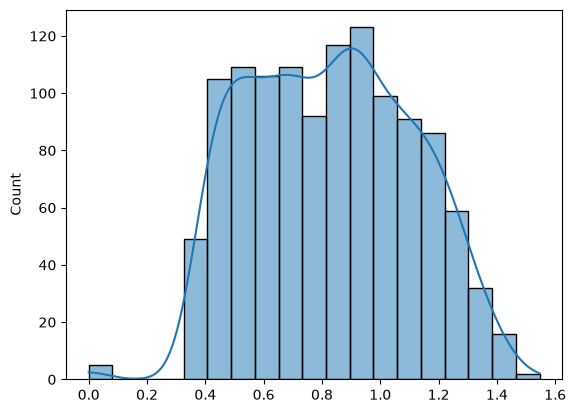

In [69]:
sns.histplot(yj_data, kde=True, bins='fd')

In [70]:
print('----Quantile Transformer----')

----Quantile Transformer----


In [71]:
QT=QuantileTransformer(output_distribution='normal', random_state=42)

In [72]:
QT_data=QT.fit_transform(up_data.reshape(-1,1)).flatten()

In [73]:
print("--- Statistical Profile: Quantile (Normal) Transformation ---")
print(f"Mean: {np.mean(QT_data):.4f} | Median: {np.median(QT_data):.4f}")
print(f"Skewness (y1): {stats.skew(QT_data):.4f} (Ideal: 0.0)")
print(f"Excess Kurtosis (y2): {stats.kurtosis(QT_data):.4f} (Ideal: 0.0)\n")
 

--- Statistical Profile: Quantile (Normal) Transformation ---
Mean: -0.0076 | Median: -0.0004
Skewness (y1): -0.3153 (Ideal: 0.0)
Excess Kurtosis (y2): 2.2092 (Ideal: 0.0)



<Axes: ylabel='Count'>

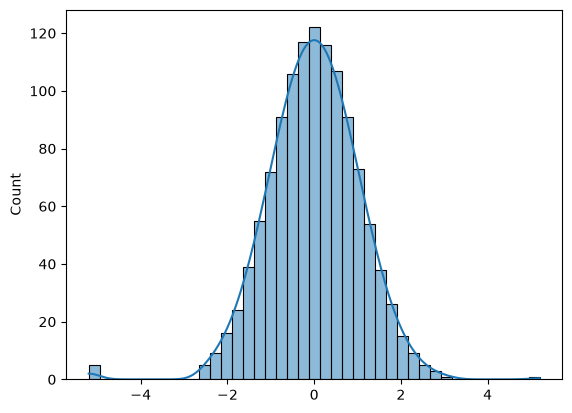

In [74]:
sns.histplot(QT_data, kde=True, bins='fd')

In [75]:
#From among all, QuantileTransformer displayed the best results. 

In [76]:
#So,finally, ascending order of compute cost: Log < Box-Cox < Yeo-Johnson < Quantile.